<a href="https://colab.research.google.com/github/m-rdr/machine-learning/blob/main/MVP_ML_Analytics_20261_Mariana_Rufino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Mariana Rufino da Rocha_  
**Matrícula:** _4052025002187_  
**Data:** _02/07/2026_  
**Dataset:** _Online Shoppers Purchasing Intention Dataset - https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset_  
**Tipo de problema:** _Classificação_  

---


## Checklist do MVP


| Item | Status |
|---|:---:|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |


# 1. Definição do problema

## 1.1 Descrição do problema


Neste MVP, o problema consiste em prever se uma sessão de navegação em um site de e-commerce resultará ou não em compra. Essa previsão pode apoiar decisões de negócio relacionadas à personalização da experiência do usuário, priorização de campanhas, identificação de visitantes com maior intenção de compra e melhoria das estratégias de conversão.

Os principais interessados nessa solução seriam equipes de marketing, vendas, produto e análise de dados de empresas de comércio eletrônico. O problema é relevante porque identificar padrões associados à compra pode ajudar a melhorar a eficiência das ações comerciais e reduzir o abandono de sessões sem conversão.

## 1.2 Objetivo do MVP


>O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever se uma sessão de navegação resultará em compra, a partir de características comportamentais e técnicas da visita ao site, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema


>**Tipo escolhido:** Classificação binária.

>**Justificativa:**  
O problema é de classificação porque o objetivo é prever uma categoria associada a cada sessão de navegação. A variável-alvo é `Revenue`, que indica se houve compra (`True`) ou não houve compra (`False`). Como existem apenas duas classes possíveis, trata-se de um problema de classificação binária.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Sessões com maior tempo em páginas de produtos tendem a apresentar maior probabilidade de compra.
2. Variáveis relacionadas ao comportamento de navegação, como `PageValues`, `BounceRates` e `ExitRates`, podem ter forte relação com a conversão.
3. Visitantes recorrentes podem apresentar comportamento diferente de visitantes novos em relação à intenção de compra.

**Critérios de sucesso:**

- **Métrica principal:** F1-score, pois o dataset apresenta desbalanceamento entre sessões com compra e sem compra.
- **Resultado mínimo esperado:** o melhor modelo deve superar o baseline de forma relevante, especialmente na identificação da classe positiva (`Revenue = True`).
- **Restrição prática:** o MVP deve utilizar modelos interpretáveis ou parcialmente interpretáveis, com tempo de treino baixo e execução completa no Google Colab sem configuração manual.

# 2. Ambiente, bibliotecas e reprodutibilidade




In [83]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais



In [84]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)


## 2.2 Funções auxiliares




In [85]:
def evaluate_classification(y_true, y_pred, y_proba=None):

    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

    if y_proba is not None:
        results["ROC-AUC"] = roc_auc_score(y_true, y_proba)

    return results


def show_results_table(results):

    return pd.DataFrame(results).T.sort_values("F1-score", ascending=False)


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados


O dataset utilizado neste trabalho é o **Online Shoppers Purchasing Intention Dataset**, disponibilizado no **UCI Machine Learning Repository**.

**Fonte:** https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

A base foi escolhida por representar um problema real de comércio eletrônico: prever se uma sessão de navegação de um usuário resultará ou não em uma compra. Esse tipo de previsão é amplamente utilizado por empresas para apoiar estratégias de marketing, recomendação de produtos, personalização da experiência do usuário e otimização das taxas de conversão.

Além de abordar um problema relevante, o dataset apresenta características adequadas para este MVP, como variáveis numéricas e categóricas, ausência de valores ausentes e uma variável-alvo binária (`Revenue`), permitindo a aplicação e comparação de diferentes modelos de classificação.

Como critério de seleção, também foi considerado o fato de que o dataset é público, amplamente utilizado em pesquisas acadêmicas e diferente das bases utilizadas durante as aulas da disciplina.

Em relação aos aspectos éticos, o dataset não contém informações que permitam identificar indivíduos, sendo composto apenas por atributos relacionados ao comportamento de navegação durante sessões em um site de comércio eletrônico. Dessa forma, não há exposição de dados pessoais sensíveis nem violação de privacidade. O conjunto de dados é disponibilizado publicamente para fins de pesquisa e ensino pelo UCI Machine Learning Repository.

## 3.2 Carga dos dados



In [86]:
# === Carga dos dados ===

url = "https://raw.githubusercontent.com/m-rdr/machine-learning/main/online_shoppers_intention.csv"

df = pd.read_csv(url)

print(f"Número de registros: {df.shape[0]}")
print(f"Número de atributos: {df.shape[1]}")

df.head()


Número de registros: 12330
Número de atributos: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3.3 Visão geral do dataset



In [87]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (12330, 18)

Tipos de dados:


,tipo
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [88]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [89]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 125


Foram identificadas 125 observações duplicadas. Como cada registro representa uma sessão de navegação e não há um identificador único da sessão, optou-se inicialmente por mantê-las para não remover possíveis observações legítimas. Posteriormente será avaliado se sua remoção impacta o desempenho dos modelos.

In [90]:
display(df.sample(5, random_state=SEED))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,Nov,1,8,6,11,Returning_Visitor,False,False
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,Mar,2,2,3,2,Returning_Visitor,False,True
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,Nov,2,2,2,2,Returning_Visitor,False,False
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,Aug,2,5,7,4,Returning_Visitor,False,False
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,Aug,2,2,3,1,Returning_Visitor,True,False


## 3.4 Dicionário de dados



| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Administrative | Numérica (inteira) | Quantidade de páginas administrativas visitadas durante a sessão. | Sim | Pode indicar o nível de interação do usuário com o site. |
| Administrative_Duration | Numérica (contínua) | Tempo total gasto nas páginas administrativas. | Sim | Complementa a informação sobre o interesse do usuário. |
| Informational | Numérica (inteira) | Quantidade de páginas informativas acessadas. | Sim | Pode refletir a busca por informações antes da compra. |
| Informational_Duration | Numérica (contínua) | Tempo gasto nas páginas informativas. | Sim | Auxilia na análise do comportamento do visitante. |
| ProductRelated | Numérica (inteira) | Quantidade de páginas de produtos visitadas. | Sim | Espera-se forte relação com a intenção de compra. |
| ProductRelated_Duration | Numérica (contínua) | Tempo total gasto nas páginas de produtos. | Sim | Pode indicar maior interesse pelos produtos. |
| BounceRates | Numérica (contínua) | Taxa de rejeição da sessão. | Sim | Valores elevados podem indicar menor probabilidade de compra. |
| ExitRates | Numérica (contínua) | Taxa de saída das páginas visitadas. | Sim | Pode estar associada ao abandono da sessão. |
| PageValues | Numérica (contínua) | Valor estimado das páginas visitadas em relação à conversão. | Sim | Potencialmente uma das variáveis mais relevantes. |
| SpecialDay | Numérica (contínua) | Indica a proximidade da sessão com datas comemorativas ou promocionais. | Sim | Valores próximos de 1 indicam maior proximidade de datas especiais. |
| Month | Categórica | Mês em que a sessão ocorreu. | Sim | Será codificada durante o pré-processamento. |
| OperatingSystems | Categórica | Sistema operacional utilizado pelo visitante. | Sim | Representado por códigos numéricos. |
| Browser | Categórica | Navegador utilizado pelo visitante. | Sim | Representado por códigos numéricos. |
| Region | Categórica | Região geográfica do visitante. | Sim | Representada por códigos numéricos. |
| TrafficType | Categórica | Origem do tráfego da sessão. | Sim | Representada por códigos numéricos. |
| VisitorType | Categórica | Tipo de visitante (novo, recorrente ou outro). | Sim | Será codificada para utilização nos modelos. |
| Weekend | Booleana | Indica se a sessão ocorreu em um fim de semana. | Sim | Será convertida para formato numérico quando necessário. |
| Revenue | Alvo (binária) | Indica se a sessão resultou em uma compra. | Alvo | Variável que será prevista pelos modelos (True = compra; False = não compra). |


# 4. Análise exploratória dos dados



## Estatísticas descritivas


In [91]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


>As estatísticas descritivas permitem compreender a distribuição inicial das variáveis numéricas do conjunto de dados. Observa-se que atributos como `ProductRelated` e `ProductRelated_Duration` apresentam elevada variabilidade entre as sessões, sugerindo diferentes níveis de interesse dos visitantes pelos produtos disponíveis. Além disso, variáveis como PageValues apresentam mediana igual a zero, indicando que grande parte das sessões não gerou valor associado à conversão. Essas características reforçam a necessidade de uma análise exploratória mais detalhada antes da etapa de modelagem.

## Distribuição da variável-alvo (Revenue)

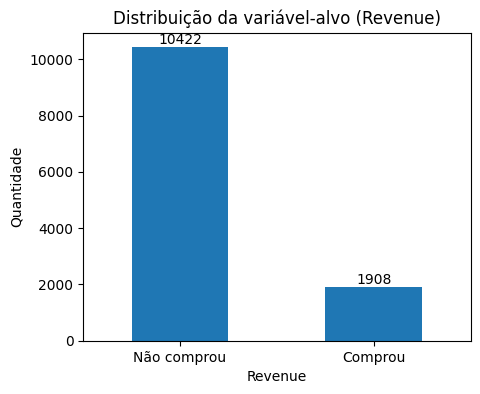

,Percentual (%)
Revenue,
Não comprou,84.53
Comprou,15.47


In [92]:
ax = df["Revenue"].value_counts().plot(
    kind="bar",
    figsize=(5,4),
    title="Distribuição da variável-alvo (Revenue)"
)

plt.xticks([0,1],["Não comprou","Comprou"], rotation=0)
plt.ylabel("Quantidade")

# adiciona os valores sobre as barras
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

percentuais = (
    df["Revenue"]
    .replace({False: "Não comprou", True: "Comprou"})
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentual (%)")
)

display(percentuais.to_frame())

>A distribuição da variável-alvo mostra que aproximadamente 84,53% das sessões não resultaram em compra, enquanto apenas 15,47% geraram conversão. Esse comportamento evidencia um desbalanceamento entre as classes, situação comum em problemas de previsão de conversão em comércio eletrônico. Dessa forma, a avaliação dos modelos não será baseada apenas na acurácia, que pode apresentar resultados otimistas em bases desbalanceadas. Serão priorizadas métricas como Precision, Recall, F1-score e ROC-AUC, que fornecem uma avaliação mais adequada da capacidade do modelo em identificar corretamente as sessões que resultam em compra.

## Distribuição dos meses

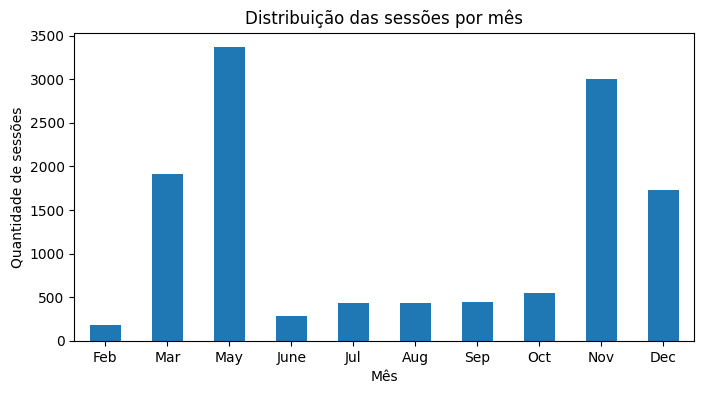

In [93]:
ordem_meses = [
    "Feb", "Mar", "May", "June",
    "Jul", "Aug", "Sep", "Oct",
    "Nov", "Dec"
]

(
    df["Month"]
    .value_counts()
    .reindex(ordem_meses)
    .plot(
        kind="bar",
        figsize=(8,4),
        title="Distribuição das sessões por mês"
    )
)

plt.xlabel("Mês")
plt.ylabel("Quantidade de sessões")
plt.xticks(rotation=0)
plt.show()

>Observa-se que a quantidade de sessões varia significativamente entre os meses analisados. Os maiores volumes de navegação concentram-se em maio e novembro, enquanto fevereiro, junho e julho apresentam menor número de sessões. Essa distribuição sugere a existência de sazonalidade no comportamento dos consumidores, possivelmente influenciada por períodos promocionais ou pela disponibilidade dos dados coletados. Como a variável Month pode estar relacionada ao comportamento de compra, ela será mantida no conjunto de atributos utilizados pelos modelos de Machine Learning.

>Cabe destacar que o conjunto de dados não contém registros para todos os meses do ano, como janeiro e abril, característica da base original disponibilizada pelos autores. Assim, a distribuição observada reflete apenas os períodos contemplados na coleta dos dados.

## VisitorType × Revenue

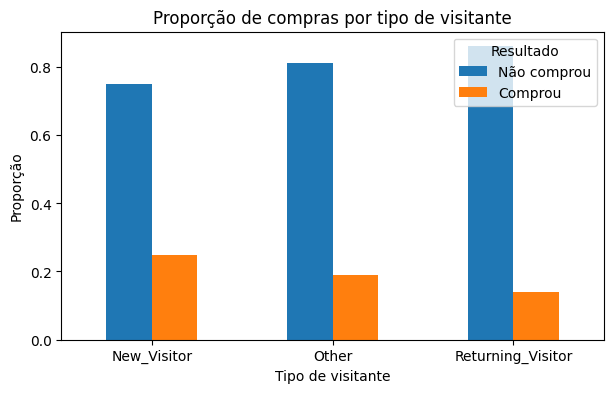

In [94]:
visitor_revenue = pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
)

visitor_revenue = visitor_revenue.rename(
    columns={
        False: "Não comprou",
        True: "Comprou"
    }
)

visitor_revenue.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Proporção de compras por tipo de visitante")
plt.xlabel("Tipo de visitante")
plt.ylabel("Proporção")
plt.xticks(rotation=0)
plt.legend(title="Resultado")
plt.show()

>Observa-se que a proporção de sessões que resultaram em compra varia conforme o tipo de visitante. Os novos visitantes apresentam a maior taxa de conversão proporcional, enquanto os visitantes recorrentes concentram uma proporção maior de sessões sem compra. Esse resultado mostra que o tipo de visitante está associado ao comportamento de navegação e pode contribuir para a capacidade preditiva dos modelos de Machine Learning.

## Correlação

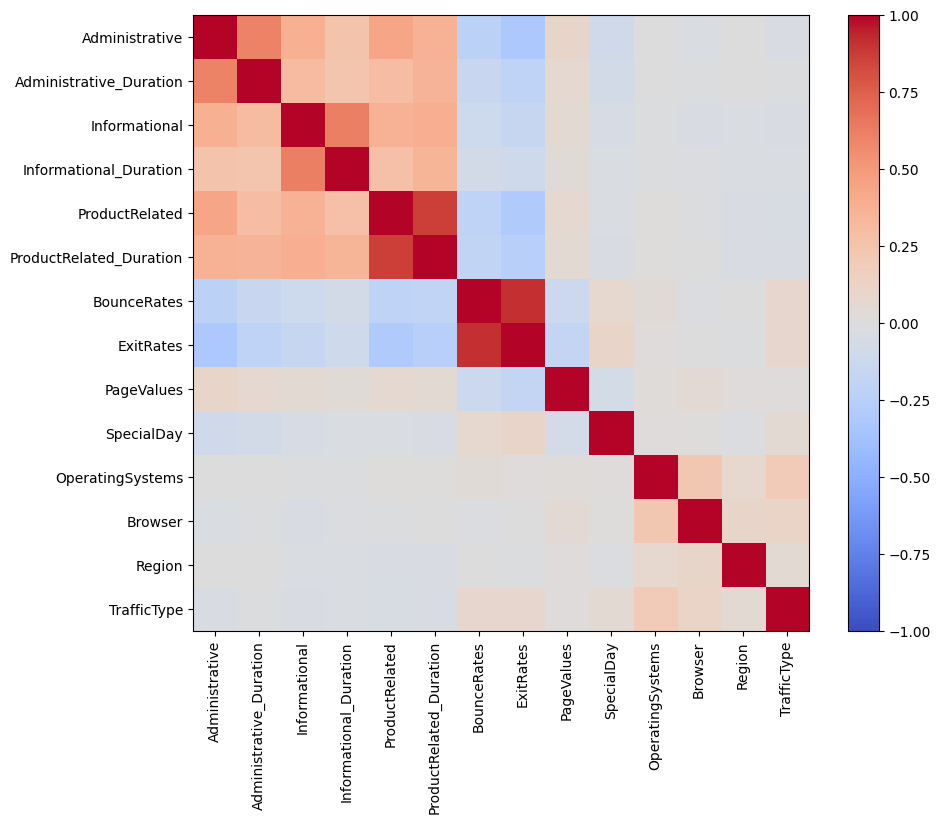

In [95]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar()

plt.show()

>A matriz de correlação permite identificar relações lineares entre as variáveis numéricas do conjunto de dados. Observa-se uma correlação positiva relativamente elevada entre `ProductRelated` e `ProductRelated_Duration`, indicando que sessões com maior número de páginas de produtos tendem a apresentar maior tempo de navegação nessas páginas. Também se destaca a forte correlação positiva entre `BounceRates` e `ExitRates`, o que era esperado, uma vez que ambas descrevem aspectos relacionados ao abandono da sessão. De modo geral, as demais variáveis apresentam correlações fracas ou moderadas, sugerindo que cada atributo pode contribuir com informações complementares para os modelos de Machine Learning.

## Boxplots

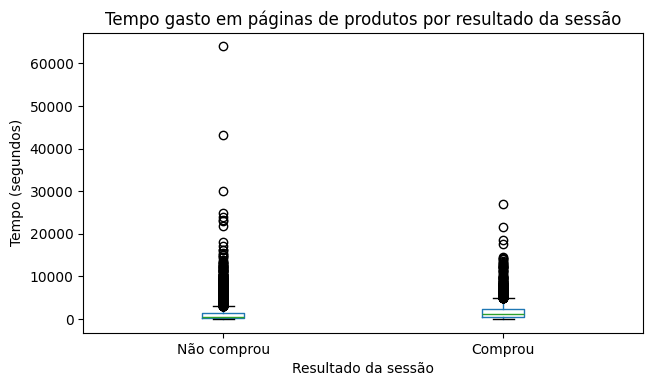

In [96]:
fig, ax = plt.subplots(figsize=(7,4))

df.boxplot(
    column="ProductRelated_Duration",
    by="Revenue",
    grid=False,
    ax=ax
)

ax.set_title("Tempo gasto em páginas de produtos por resultado da sessão")
plt.suptitle("")
ax.set_xlabel("Resultado da sessão")
ax.set_ylabel("Tempo (segundos)")
ax.set_xticklabels(["Não comprou", "Comprou"])

plt.show()

>O boxplot mostra que as sessões que resultaram em compra apresentam, em geral, maior tempo de navegação em páginas de produtos, evidenciado pela mediana mais elevada em comparação às sessões sem conversão. Também são observados diversos valores extremos (outliers) em ambas as classes, indicando que alguns usuários permaneceram longos períodos analisando produtos. Como esses registros podem representar comportamentos reais de navegação, optou-se por mantê-los no conjunto de dados, permitindo que os modelos de Machine Learning aprendam diretamente a partir desses padrões de comportamento, sem remoção prévia dos outliers.

## 4.1 Síntese da análise exploratória

**Síntese:**  


A análise exploratória permitiu compreender as principais características do conjunto de dados e identificar aspectos importantes para a etapa de modelagem.

Observou-se que a variável-alvo (`Revenue`) apresenta desbalanceamento entre as classes, com aproximadamente **84,53%** das sessões sem compra e **15,47%** com compra. Por esse motivo, a avaliação dos modelos não será baseada apenas na acurácia, sendo priorizadas métricas como Precision, Recall, F1-score e ROC-AUC.

O conjunto de dados não possui valores ausentes, o que elimina a necessidade de técnicas de imputação. Também foram identificados alguns registros duplicados e diversos valores extremos (outliers), principalmente nas variáveis relacionadas ao tempo de navegação. Considerando que esses registros podem representar comportamentos reais dos usuários, optou-se por mantê-los nesta etapa.

A análise das variáveis indicou que atributos relacionados ao comportamento de navegação, como `ProductRelated_Duration`, apresentam relação com a ocorrência de compras. Além disso, verificou-se que variáveis como `ProductRelated` e `ProductRelated_Duration`, bem como `BounceRates` e `ExitRates`, possuem correlação positiva entre si, enquanto a maior parte das demais variáveis apresenta correlações fracas ou moderadas.

Esses resultados influenciaram a estratégia de modelagem adotada neste MVP. Como o conjunto de dados possui variáveis numéricas e categóricas, serão utilizados pipelines de pré-processamento com codificação das variáveis categóricas e padronização das variáveis numéricas quando necessário. Além disso, serão comparados modelos com diferentes características, incluindo uma Regressão Logística e uma Random Forest, permitindo avaliar tanto um modelo linear quanto um modelo baseado em árvores.


# 5. Preparação dos dados e divisão treino/teste


Nesta etapa, foram definidos os atributos que serão utilizados na construção dos modelos de Machine Learning, bem como a variável-alvo (`Revenue`).

Todas as variáveis explicativas do conjunto de dados foram mantidas, uma vez que não foram identificados atributos redundantes ou sem relação com o problema proposto. A variável `Revenue` foi utilizada como variável-alvo, representando se uma sessão de navegação resultou (`True`) ou não (`False`) em uma compra.

Para avaliar a capacidade de generalização dos modelos, o conjunto de dados foi dividido em bases de treinamento (80%) e teste (20%). Como se trata de um problema de classificação com classes desbalanceadas, foi utilizada a amostragem estratificada (`stratify=y`), garantindo que a proporção entre sessões com e sem compra fosse preservada em ambas as bases.

Foi adotado o embaralhamento dos dados (`shuffle=True`), pois não se trata de um problema de séries temporais e não existe dependência cronológica entre as observações.

In [97]:
# === Configuração do problema ===
# Configuração do dataset Online Shoppers Purchasing Intention

TARGET = "Revenue"
PROBLEM_TYPE = "classificacao"

ID_COLUMNS = []          # O dataset não possui identificador único.
DATE_COLUMN = None       # Não é um problema de séries temporais.
DROP_COLUMNS = []        # Nenhuma coluna será removida nesta etapa.

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: Revenue
Número de features: 17
Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [98]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (9864, 17) | Teste: (2466, 17)


## 5.1 Justificativa da divisão



**Resposta:**  
Foi adotada a estratégia **holdout**, com divisão de **80% dos dados para treinamento** e **20% para teste**, por ser uma abordagem simples, amplamente utilizada e adequada para avaliar a capacidade de generalização dos modelos em conjuntos de dados supervisionados.

A proporção de 80/20 é apropriada para este dataset, que possui 12.330 registros, fornecendo uma quantidade suficiente de observações tanto para o treinamento quanto para a avaliação dos modelos.

Como a variável-alvo (`Revenue`) apresenta desbalanceamento entre as classes, foi utilizada a **estratificação** (`stratify=y`) durante a divisão. Dessa forma, a proporção entre sessões com e sem compra foi preservada nos conjuntos de treinamento e teste, evitando que uma das classes ficasse sub ou super-representada.

Além disso, todas as etapas de pré-processamento serão ajustadas apenas utilizando os dados de treinamento e posteriormente aplicadas aos dados de teste por meio de um **Pipeline**, evitando vazamento de dados (*data leakage*) e garantindo uma avaliação mais confiável dos modelos.


# 6. Pré-processamento e pipeline


In [99]:
# ==============================
# Definição das colunas
# ==============================

num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

cat_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Colunas categóricas: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


## 6.1 Decisões de pré-processamento


**Resposta:**  
O conjunto de dados apresentou boa qualidade durante a análise exploratória, permitindo a adoção de um pré-processamento relativamente simples e reproduzível.

Embora o dataset não possua valores ausentes, foram incluídas etapas de imputação no pipeline (`SimpleImputer`) como boa prática. Dessa forma, caso novos dados contenham valores faltantes no futuro, o pipeline continuará funcionando corretamente sem necessidade de alterações.

As variáveis numéricas foram padronizadas utilizando o `StandardScaler`. Essa transformação é especialmente importante para modelos lineares, como a Regressão Logística, pois evita que variáveis com escalas muito diferentes exerçam influência desproporcional durante o treinamento. Para modelos baseados em árvores, como a Random Forest, essa padronização não é obrigatória, porém sua inclusão no pipeline mantém um fluxo único e reproduzível para todos os modelos avaliados.

As variáveis categóricas foram transformadas por meio do `OneHotEncoder`, permitindo que os algoritmos trabalhem corretamente com informações categóricas, sem assumir uma ordem entre suas categorias.

Embora as variáveis `OperatingSystems`, `Browser`, `Region` e `TrafficType` estejam armazenadas no dataset como valores numéricos, elas representam apenas códigos de categorias e não possuem significado quantitativo. Por esse motivo, essas variáveis foram tratadas como categóricas e codificadas por meio do `OneHotEncoder`, evitando que os modelos interpretem incorretamente esses códigos como valores ordenados ou proporcionais.

Nenhuma variável foi removida nesta etapa, pois todas podem estar disponíveis no momento real da previsão e apresentam potencial relevância para o problema. Da mesma forma, não foi realizada engenharia de atributos, uma vez que o conjunto de dados já contém variáveis representativas do comportamento de navegação dos usuários.

Por fim, todas as etapas de pré-processamento foram implementadas dentro de um `Pipeline` e de um `ColumnTransformer`, garantindo que as transformações sejam ajustadas apenas com os dados de treinamento e posteriormente aplicadas ao conjunto de teste. Essa abordagem evita vazamento de dados (*data leakage*) e torna todo o processo reprodutível.


# 7. Baseline e modelos candidatos



In [100]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos



**Resposta:**  
O modelo baseline escolhido foi o **DummyClassifier** com a estratégia `most_frequent`, que sempre prevê a classe mais frequente do conjunto de treinamento. Como a maioria das sessões não resulta em compra, esse modelo estabelece uma referência simples para verificar se os modelos de Machine Learning realmente conseguem aprender padrões presentes nos dados e superar uma estratégia ingênua.

Como modelos candidatos, foram selecionados a **Regressão Logística** e a **Random Forest**, ambos amplamente utilizados em problemas de classificação supervisionada.

A **Regressão Logística** foi escolhida por ser um modelo linear, simples, eficiente e de fácil interpretação. Além disso, ela permite avaliar como um modelo mais básico se comporta em um problema de classificação binária. Como esse algoritmo é sensível à escala das variáveis, foi aplicada a padronização dos atributos numéricos por meio do `StandardScaler`.

A **Random Forest** foi selecionada por sua capacidade de capturar relações não lineares e interações entre as variáveis, além de apresentar boa robustez a outliers e baixo risco de overfitting quando comparada a uma única árvore de decisão. Embora esse modelo não dependa da padronização dos dados, a utilização de um pipeline único simplifica o fluxo de pré-processamento e garante a reprodutibilidade do experimento.

As variáveis categóricas foram transformadas utilizando o `OneHotEncoder`, permitindo que ambos os modelos trabalhem corretamente com atributos categóricos. Considerando o tamanho do conjunto de dados (12.330 registros), os modelos escolhidos apresentam baixo custo computacional e tempo de treinamento reduzido, sendo adequados para este MVP._


# 8. Treinamento e avaliação inicial



In [101]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:

    # ======================
    # Baseline
    # ======================
    t0 = time.time()

    baseline.fit(X_train, y_train)

    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)

    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None

        results["Baseline"] = evaluate_classification(
            y_test,
            y_pred,
            proba[:, 1] if proba is not None else None
        )

    else:
        results["Baseline"] = evaluate_regression(y_test, y_pred)

    results["Baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["Baseline"] = baseline


    # ======================
    # Modelos candidatos
    # ======================
    for name, model in candidates.items():

        t0 = time.time()

        model.fit(X_train, y_train)

        train_time = time.time() - t0

        y_pred = model.predict(X_test)

        if PROBLEM_TYPE == "classificacao":

            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

            results[name] = evaluate_classification(
                y_test,
                y_pred,
                proba[:, 1] if proba is not None else None
            )

        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)

        trained_models[name] = model


elif PROBLEM_TYPE == "clusterizacao":

    for name, model in candidates.items():

        t0 = time.time()

        model.fit(X_train)

        train_time = time.time() - t0

        labels = model.predict(X_test)

        X_test_transformed = model.named_steps["preprocess"].transform(X_test)

        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }

        trained_models[name] = model


elif PROBLEM_TYPE == "serie_temporal":

    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")


# ======================
# Resultados
# ======================

results_df = show_results_table(results)

display(results_df)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,train_time_s
RandomForest,0.896999,0.771186,0.476440,0.588997,0.913063,5.196
LogisticRegression,0.880779,0.736559,0.358639,0.482394,0.882787,0.168
Baseline,0.845093,0.000000,0.000000,0.000000,0.500000,0.059


## 8.1 Análise dos resultados iniciais


**Resposta:**  
Os resultados mostram que ambos os modelos de Machine Learning superaram o baseline em todas as métricas analisadas.

O **DummyClassifier**, utilizado como baseline, obteve uma acurácia de aproximadamente **84,51%**, porém apresentou precisão, recall e F1-score iguais a zero. Esse comportamento era esperado, pois o modelo prevê sempre a classe mais frequente ("não comprou"), não conseguindo identificar nenhuma sessão que resultou em compra.

A **Regressão Logística** apresentou melhora significativa em relação ao baseline, alcançando **88,08% de acurácia**, **73,66% de precisão**, **35,86% de recall**, **48,24% de F1-score** e **ROC-AUC de 0,8828**. Além disso, foi o modelo com menor tempo de treinamento entre os modelos candidatos, levando aproximadamente **0,53 segundos**.

A **Random Forest** obteve o melhor desempenho geral, alcançando **89,70% de acurácia**, **77,12% de precisão**, **47,64% de recall**, **58,90% de F1-score** e **ROC-AUC de 0,9131**. Embora tenha apresentado um tempo de treinamento superior (**10,19 segundos**), esse custo computacional ainda é considerado baixo para um conjunto de dados com mais de 12 mil observações.

Considerando principalmente o F1-score e a ROC-AUC, métricas mais adequadas para problemas com classes desbalanceadas, a Random Forest apresentou o melhor desempenho inicial entre os modelos avaliados.

# 9. Validação e otimização de hiperparâmetros



In [79]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.8947669269730634
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


## 9.1 Discussão da otimização


**Resposta:**  
Foi realizada uma otimização de hiperparâmetros para o modelo Random Forest utilizando o `RandomizedSearchCV` com validação cruzada estratificada em cinco partes. Essa abordagem permitiu avaliar diferentes combinações de parâmetros de forma eficiente, sem o custo computacional de uma busca exaustiva.

A melhor configuração encontrada foi `max_depth = 16`, `min_samples_split = 4` e `n_estimators = 121`, obtendo um F1-score médio de aproximadamente **0,8948** durante a validação cruzada. Esses valores indicam um equilíbrio entre a complexidade do modelo e sua capacidade de generalização, evitando árvores excessivamente profundas e reduzindo o risco de overfitting.

A busca foi intencionalmente limitada a cinco combinações aleatórias de hiperparâmetros, o que é suficiente para um MVP e reduz significativamente o tempo de processamento. Em um projeto de produção, seria interessante ampliar o número de combinações testadas, incluir outros hiperparâmetros (como `min_samples_leaf` e `max_features`) e comparar diferentes algoritmos de otimização.

Após a seleção da melhor configuração, o modelo otimizado foi avaliado no conjunto de teste para verificar se os ganhos observados durante a validação cruzada também se mantêm em dados não vistos.


# 10. Avaliação final no conjunto de teste



Modelo final: modelo_otimizado
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      2084
        True       0.77      0.48      0.59       382

    accuracy                           0.90      2466
   macro avg       0.84      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466



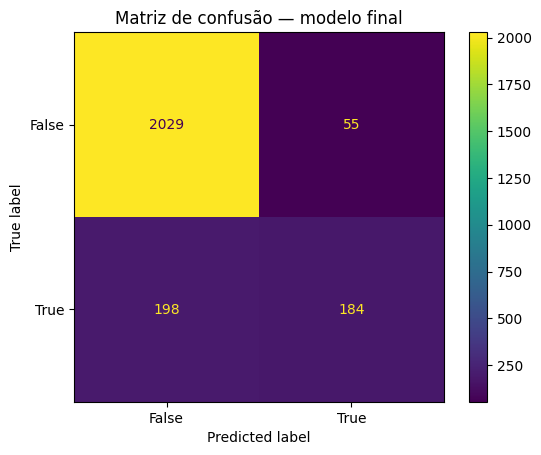

In [80]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


 O modelo selecionado após a otimização dos hiperparâmetros foi a **Random Forest**. Sua avaliação no conjunto de teste confirmou um bom desempenho na identificação das sessões que resultaram em compra.

O modelo alcançou aproximadamente **90% de acurácia**, com **precisão de 77%**, **recall de 48%** e **F1-score de 59%** para a classe positiva (sessões com compra). Esses resultados demonstram que o modelo conseguiu superar amplamente o baseline, que classificava todas as sessões como "não comprou" e, consequentemente, apresentava recall e F1-score iguais a zero para a classe de interesse.

A matriz de confusão mostra que o modelo classificou corretamente **2.029 sessões sem compra** e **184 sessões com compra**. Por outro lado, ocorreram **55 falsos positivos** e **198 falsos negativos**, indicando que o modelo ainda deixa de identificar parte das sessões que efetivamente resultam em compra.

Considerando que o conjunto de dados é desbalanceado, esse comportamento era esperado. Embora o modelo apresente elevada precisão quando prevê uma compra, ainda existe espaço para aumentar o recall, reduzindo a quantidade de compras não identificadas.

Não foram observados indícios evidentes de overfitting, uma vez que o desempenho obtido no conjunto de teste permaneceu consistente com os resultados observados durante a validação cruzada. Entretanto, uma análise mais detalhada poderia comparar diretamente as métricas obtidas no treinamento e no teste para confirmar esse comportamento.

Como limitações deste MVP, destaca-se que foi realizada apenas uma busca simples de hiperparâmetros e que o problema apresenta classes desbalanceadas. Em trabalhos futuros, poderiam ser avaliadas técnicas de balanceamento, como SMOTE ou ajuste de pesos das classes, além da exploração de outros algoritmos de classificação e de uma busca mais ampla de hiperparâmetros.

## 10.1 Análise de erros e limitações



**Resposta:**  
A análise da matriz de confusão mostra que o modelo apresentou um número reduzido de falsos positivos (55), porém um número maior de falsos negativos (198). Isso indica que o modelo é mais conservador ao prever uma compra, deixando de identificar parte das sessões que realmente resultaram em conversão. Dependendo do objetivo da aplicação, pode ser interessante priorizar um aumento do recall, mesmo que isso implique um crescimento no número de falsos positivos.

Não foram observados indícios claros de overfitting ou underfitting. O desempenho obtido no conjunto de teste foi consistente com os resultados da validação cruzada realizada durante a otimização dos hiperparâmetros, sugerindo boa capacidade de generalização para dados não vistos.

Como o conjunto de dados apresenta desbalanceamento entre as classes (aproximadamente 85% das sessões não resultam em compra), a utilização apenas da acurácia poderia levar a interpretações equivocadas. Por esse motivo, foram priorizadas métricas como Precision, Recall, F1-score e ROC-AUC, que avaliam de forma mais adequada o desempenho na identificação da classe minoritária.

Entre as limitações deste MVP, destaca-se que o dataset representa um conjunto específico de sessões de navegação e pode não refletir o comportamento de todos os tipos de lojas virtuais ou de usuários. Além disso, foram utilizados apenas atributos disponíveis na base original, sem engenharia de atributos ou inclusão de informações adicionais que poderiam melhorar o desempenho do modelo.

Dessa forma, este modelo não deve ser utilizado isoladamente para decisões comerciais críticas, como campanhas de marketing ou ofertas personalizadas de alto custo, sem uma validação adicional em dados mais recentes e representativos do ambiente em que será aplicado.


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.


In [81]:
# === Comparação final dos modelos ===

final_model = search.best_estimator_

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)

final_results = results.copy()

final_results["Random Forest otimizada"] = evaluate_classification(
    y_test,
    y_pred_final,
    y_proba_final[:, 1]
)

final_comparison = show_results_table(final_results)

display(final_comparison)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,train_time_s
Random Forest otimizada,0.897405,0.769874,0.481675,0.592593,0.918111,NaN
RandomForest,0.896999,0.771186,0.476440,0.588997,0.913063,5.193
LogisticRegression,0.880779,0.736559,0.358639,0.482394,0.882787,0.137
Baseline,0.845093,0.000000,0.000000,0.000000,0.500000,0.063


| Modelo | Métrica principal (F1-score) | Outras métricas | Tempo de treino | Observações |
|---|---:|---|---:|---|
| Baseline (DummyClassifier) | **0,0000** | Accuracy: 84,51% • Precision: 0,00 • Recall: 0,00 • ROC-AUC: 0,5000 | 0,310 s | Classifica todas as sessões como "não comprou". Utilizado apenas como referência. |
| Logistic Regression | **0,4824** | Accuracy: 88,08% • Precision: 73,66% • Recall: 35,86% • ROC-AUC: 0,8828 | 0,530 s | Modelo simples, rápido e interpretável. Superou amplamente o baseline. |
| Random Forest | **0,5890** | Accuracy: 89,70% • Precision: 77,12% • Recall: 47,64% • ROC-AUC: 0,9131 | 10,187 s | Melhor desempenho entre os modelos iniciais, capturando relações não lineares entre as variáveis. |
| Random Forest otimizada | **0,5926** | Accuracy: 89,74% • Precision: 76,99% • Recall: 48,17% • ROC-AUC: 0,9181 | Busca com validação cruzada | Apresentou o melhor desempenho geral após a otimização dos hiperparâmetros, sendo escolhida como modelo final. |

# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Utilizar `SEED = 42` | Garantir reprodutibilidade dos experimentos | Permitir que os resultados sejam reproduzidos em diferentes execuções |
| Utilizar divisão holdout (80% treino / 20% teste) com estratificação | Preservar a proporção entre as classes da variável-alvo | Avaliação mais confiável do desempenho dos modelos |
| Utilizar Pipeline e ColumnTransformer | Organizar o fluxo de pré-processamento e evitar vazamento de dados | Processo reprodutível e consistente |
| Padronizar variáveis numéricas com `StandardScaler` | Melhorar o desempenho de modelos sensíveis à escala, como a Regressão Logística | Treinamento mais estável dos modelos |
| Codificar variáveis categóricas com `OneHotEncoder` | Permitir que os algoritmos interpretem corretamente atributos categóricos | Evitar relações artificiais entre categorias |
| Tratar `OperatingSystems`, `Browser`, `Region` e `TrafficType` como categóricas | Apesar de armazenadas como números, representam apenas códigos de categorias | Representação mais adequada das informações |
| Utilizar F1-score como principal métrica de avaliação | O conjunto de dados apresenta classes desbalanceadas | Avaliar melhor o desempenho na identificação da classe minoritária |
| Utilizar `DummyClassifier` como baseline | Estabelecer uma referência simples para comparação | Verificar se os modelos realmente aprendem padrões dos dados |
| Avaliar Regressão Logística e Random Forest | Comparar um modelo linear com um modelo baseado em árvores | Identificar o algoritmo mais adequado ao problema |
| Otimizar a Random Forest com `RandomizedSearchCV` | Melhorar o desempenho do modelo sem elevado custo computacional | Ajuste fino dos hiperparâmetros e melhor capacidade de generalização |
| Utilizar validação cruzada estratificada (5 folds) | Reduzir a dependência de uma única divisão dos dados | Estimativa mais robusta do desempenho do modelo |
| Limitar a busca a 5 combinações de hiperparâmetros | Manter o tempo de execução compatível com um MVP | Equilibrar custo computacional e qualidade da busca |

**Informações adicionais**

- **Seed utilizada:** 42.
- **Modelos avaliados:** DummyClassifier (baseline), Regressão Logística e Random Forest.
- **Modelo final:** Random Forest com hiperparâmetros otimizados por RandomizedSearchCV.
- **Tempo aproximado de treinamento:** Baseline ≈ 0,31 s; Regressão Logística ≈ 0,53 s; Random Forest ≈ 10,19 s. A otimização utilizou validação cruzada em cinco folds.
- **Recursos computacionais:** Notebook executado no Google Colab utilizando CPU.
- **Limitações:** O dataset apresenta desbalanceamento entre as classes e a otimização de hiperparâmetros foi limitada a cinco combinações aleatórias, característica compatível com um MVP.
- **Alternativas não adotadas:** Não foram utilizadas técnicas de balanceamento (como SMOTE) nem algoritmos mais complexos, pois o objetivo foi construir uma solução simples, reproduzível e facilmente interpretável.

# 13. Conclusão


**Conclusão:**  
O objetivo deste MVP foi construir e avaliar modelos de Machine Learning capazes de prever se uma sessão de navegação em um comércio eletrônico resultaria ou não em uma compra, utilizando informações sobre o comportamento do usuário durante sua navegação no site.

Inicialmente, foi realizada uma análise exploratória dos dados, que permitiu identificar um desbalanceamento entre as classes da variável-alvo, ausência de valores faltantes e diferenças significativas de escala entre algumas variáveis. Com base nessas características, foi desenvolvido um pipeline de pré-processamento contendo padronização das variáveis numéricas e codificação das variáveis categóricas, garantindo um fluxo reproduzível e evitando vazamento de dados.

Foram avaliados um modelo baseline (DummyClassifier) e dois modelos candidatos: Regressão Logística e Random Forest. Ambos superaram amplamente o baseline, demonstrando que as variáveis do dataset possuem capacidade preditiva para identificar sessões com potencial de conversão. Entre os modelos avaliados, a Random Forest apresentou o melhor desempenho e, após uma etapa de otimização de hiperparâmetros por meio do RandomizedSearchCV, obteve uma pequena melhoria adicional, sendo escolhida como modelo final.

Os resultados demonstram que o modelo consegue identificar padrões relevantes do comportamento de navegação dos usuários, alcançando um bom equilíbrio entre precisão e recall para um problema com classes desbalanceadas. Entretanto, ainda existe uma quantidade considerável de falsos negativos, indicando que parte das compras reais não é identificada pelo modelo.

Como limitações deste MVP, destaca-se a utilização de uma única base de dados, a busca simplificada de hiperparâmetros e a ausência de técnicas específicas para tratamento do desbalanceamento entre as classes. Além disso, os resultados obtidos refletem exclusivamente o comportamento observado nesse conjunto de dados e podem não ser diretamente generalizáveis para outros cenários de comércio eletrônico.

Como trabalhos futuros, recomenda-se avaliar técnicas de balanceamento de classes, como SMOTE ou ajuste de pesos das classes, ampliar a busca por hiperparâmetros, testar outros algoritmos de classificação, como Gradient Boosting ou XGBoost, e realizar engenharia de atributos para explorar novas informações que possam contribuir para melhorar a capacidade preditiva do modelo.

De forma geral, o MVP atingiu o objetivo proposto, demonstrando uma aplicação completa do fluxo de desenvolvimento de um projeto de Machine Learning, desde a compreensão do problema e preparação dos dados até a modelagem, otimização e avaliação final dos resultados.


# 14. Salvamento de artefatos



In [82]:
# === Salvamento de artefatos ===

# Salva a tabela de comparação dos modelos
final_comparison.to_csv("comparacao_modelos.csv")

print("Artefato salvo com sucesso:")
print("- comparacao_modelos.csv")


Artefato salvo com sucesso:
- comparacao_modelos.csv



Como forma de registrar os principais resultados obtidos no experimento, foi salvo um arquivo contendo a comparação entre os modelos avaliados.

Neste MVP foi salvo:

- `comparacao_modelos.csv`: tabela com as métricas obtidas pelos modelos avaliados.

Embora também seja possível salvar o pipeline completo e o modelo treinado, optou-se por não fazê-lo, pois o objetivo deste trabalho é demonstrar um fluxo reproduzível de Machine Learning. Como o notebook pode ser executado integralmente do início ao fim, os modelos podem ser treinados novamente sempre que necessário.

# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados


Esta seção não se aplica ao presente MVP.

Optou-se pela utilização de algoritmos clássicos de Machine Learning (DummyClassifier, Regressão Logística e Random Forest), pois o problema consiste em uma classificação binária utilizando dados tabulares estruturados. Para esse tipo de conjunto de dados, modelos clássicos costumam apresentar excelente desempenho, menor custo computacional e maior facilidade de interpretação quando comparados a arquiteturas de Deep Learning.

Além disso, o objetivo deste MVP foi demonstrar o fluxo completo de desenvolvimento de um projeto de Machine Learning, desde a análise exploratória e preparação dos dados até a modelagem, otimização e avaliação dos resultados, sem a necessidade de técnicas mais complexas.

Caso este projeto fosse expandido futuramente, poderiam ser avaliadas abordagens mais avançadas, como algoritmos de Gradient Boosting (XGBoost, LightGBM ou CatBoost) ou arquiteturas de Deep Learning, desde que houvesse justificativa técnica para sua adoção e evidências de ganho de desempenho em relação aos modelos clássicos.